# Optional Project - Transformer Scaling Laws on SVGs

Vincent Hepola - vh2308


# 0. Imports


In [41]:
from IPython.display import SVG, display
from datasets import load_dataset
import torch

import torch.nn as nn

import torch.nn.functional as F

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

from lxml import etree
import cairosvg

import numpy as np
from tqdm.auto import tqdm

import re

# 1. Data Collecting and Preprocessing


## 1.1 Dataset


In [42]:
dataset = load_dataset("starvector/svg-icons-simple")

In [43]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 80434
    })
    test: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 2682
    })
    val: Dataset({
        features: ['Filename', 'Svg'],
        num_rows: 6254
    })
})

In [44]:
train_data = dataset["train"]

In [45]:
svgs = np.array(train_data["Svg"])

In [46]:
svgs

array(['<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.196237564086914 4.810017108917236 10.606165885925293 5.704833984375 8.710693359375 C6.279782772064209 7.492790699005127 8.955889701843262 7.426052093505859 10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432"></path>\n<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 9.215624809265137 L10.059374809265137 9.215624809265137 C10.72203254699707 9.315858840942383 14.316993713378906 10.194662094116211 11.5437507629394

### View Sample


In [47]:
sample_1 = svgs[0]

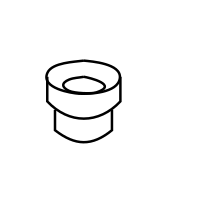

In [48]:
display(SVG(sample_1))

## 1.2 Normalizing/Cleaning

- Strip comments, metadata, and unnecessary whitespace
- Normalize coordinate precision (e.g., round to 1 decimal place) to reduce vocabulary
- Optionally canonicalize attribute ordering
- Remove SVGs that are too short (< 50 characters) or too long (above your chosen token threshold)
- Validate that all SVGs in the cleaned set parse as valid XML
- Ensure all SVGs render without errors (use lxml for XML parsing, optionally CairoSVG for render validation)


In [49]:
def clean_svg(svg_text):
    # Remove XML comments
    svg_text = re.sub(r"", "", svg_text, flags=re.DOTALL)

    # Normalize coordinates to 1 decimal place
    # \d+\.\d+ captures numbers like 0.0, 1.323, 123.4
    # Does not capture numbers like .0, 1, or 1.
    svg_text = re.sub(r"\d+\.\d+", lambda m: str(round(float(m.group(0)), 1)), svg_text)

    # Strip extra whitespace, leaving single-spaced text with no leading/trailing space
    svg_text = re.sub(r"\s+", " ", svg_text).strip()

    return svg_text

In [50]:
print(sample_1)
svg_string = clean_svg(sample_1)

print()
print(svg_string)

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432 C10.977089881896973 7.366771697998047 14.58566665649414 7.627137660980225 14.384374618530273 9.36875057220459 C14.17175006866455 11.208415031433105 10.620377540588379 11.302374839782715 9.46875 11.240625381469727 C8.640908241271973 11.196237564086914 4.810017108917236 10.606165885925293 5.704833984375 8.710693359375 C6.279782772064209 7.492790699005127 8.955889701843262 7.426052093505859 10.059374809265137 7.275000095367432 L10.059374809265137 7.275000095367432"></path>
<path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0"  filling="0" d="M10.059374809265137 9.215624809265137 L10.059374809265137 9.215624809265137 C10.72203254699707 9.315858840942383 14.316993713378906 10.194662094116211 11.543750762939453 11.096

In [51]:
TOKEN_THRESHOLD = 4096

# count = 0

# # print(len(dataset["train"]))

# for svg in tqdm(svgs):
#     svg_string  = clean_svg(svg)
#     # print(len(svg_string))
#     if len(svg_string) <= TOKEN_THRESHOLD:
#         count += 1

In [52]:
# print(count/len(dataset["train"]))

### Clean and verify all svgs in training set


In [53]:
def dict_map(d):
    cleaned_string = clean_svg(d["Svg"])
    return {"Filename": d["Filename"], "Svg": cleaned_string}


cleaned_train = train_data.map(dict_map)

In [54]:
print(f"cleaned_train.num_rows: {cleaned_train.num_rows}")

cleaned_train.num_rows: 80434


In [55]:
def is_valid(d):
    svg_string = d["Svg"]

    if len(svg_string) <= 50 or len(svg_string) > TOKEN_THRESHOLD:
        return False

    try:
        etree.fromstring(svg_string.encode("utf-8"))
    except etree.XMLSyntaxError:
        return False

    return True


def valid_render(d):
    svg_string = d["Svg"]

    try:
        cairosvg.svg2png(bytestring=svg_string.encode("utf-8"))
    except:
        return False

    return True


filtered_train = cleaned_train.filter(is_valid)
# filtered_train = filtered_train.filter(valid_render)

In [56]:
print(f"filtered_train.num_rows: {filtered_train.num_rows}")

filtered_train.num_rows: 71239


In [57]:
filtered_train

Dataset({
    features: ['Filename', 'Svg'],
    num_rows: 71239
})

## 1.3 Tokenize

Train a BPE tokenizer on your SVG corpus using sentencepiece or the HuggingFace
tokenizers library. Vocabulary sizes in the range 1K–8K are reasonable. Document the vocabulary
size and justify your choice in the report.


In [58]:
VOCAB_SIZE = 1000
BLOCK_SIZE = 256

In [59]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [60]:
tokenizer = Tokenizer(models.BPE())

tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(
    special_tokens=["<|endoftext|>", "<|pad|>"], vocab_size=VOCAB_SIZE
)

In [61]:
tokenizer

Tokenizer(version="1.0", truncation=None, padding=None, added_tokens=[], normalizer=None, pre_tokenizer=Whitespace(), post_processor=None, decoder=None, model=BPE(dropout=None, unk_token=None, continuing_subword_prefix=None, end_of_word_suffix=None, fuse_unk=False, byte_fallback=False, ignore_merges=False, vocab={}, merges=[]))

In [62]:
tokenizer.train_from_iterator(filtered_train["Svg"], trainer)

In [63]:
sample_2 = filtered_train["Svg"][0]
sample_2

'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 24.0 24.0" height="200px" width="200px"><path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 7.3 L10.1 7.3 C11.0 7.4 14.6 7.6 14.4 9.4 C14.2 11.2 10.6 11.3 9.5 11.2 C8.6 11.2 4.8 10.6 5.7 8.7 C6.3 7.5 9.0 7.4 10.1 7.3 L10.1 7.3"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M10.1 9.2 L10.1 9.2 C10.7 9.3 14.3 10.2 11.5 11.1 C11.0 11.3 9.0 11.2 8.3 10.9 C7.4 10.5 7.3 10.0 8.3 9.6 C8.8 9.3 9.5 9.3 10.1 9.2 L10.1 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M14.4 9.2 L14.4 12.2 C13.1 13.5 11.6 14.2 10.1 14.2 C8.5 14.2 7.0 13.5 5.7 12.2 L5.7 9.2"></path> <path fill="none" stroke="black" stroke-width=".3" stroke-opacity="1.0" filling="0" d="M13.4 13.2 L13.4 15.6 C12.2 16.6 11.1 17.1 10.0 17.1 C8.9 17.1 7.8 16.6 6.6 15.6 L6.6 13.2"></path></svg>'

In [64]:
encoded_sample_2 = tokenizer.encode(sample_2)

print(encoded_sample_2)


# First 10 tokens on encoding
for id, token in zip(encoded_sample_2.ids[:10], encoded_sample_2.tokens[:10]):
    print(f"{id} -> {token}")

Encoding(num_tokens=460, attributes=[ids, type_ids, tokens, offsets, attention_mask, special_tokens_mask, overflowing])
17 -> <
94 -> svg
148 -> xmlns
46 -> ="
142 -> http
126 -> ://
143 -> www
4 -> .
138 -> w3
4 -> .


In [65]:
tokenizer.decode(encoded_sample_2.ids)

'< svg xmlns =" http :// www . w3 . org / 2000 / svg " viewBox =" 0 . 0 0 . 0 24 . 0 24 . 0 " height =" 200px " width =" 200px ">< path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M10 . 1 7 . 3 L10 . 1 7 . 3 C11 . 0 7 . 4 14 . 6 7 . 6 14 . 4 9 . 4 C14 . 2 11 . 2 10 . 6 11 . 3 9 . 5 11 . 2 C8 . 6 11 . 2 4 . 8 10 . 6 5 . 7 8 . 7 C6 . 3 7 . 5 9 . 0 7 . 4 10 . 1 7 . 3 L10 . 1 7 . 3 "></ path > < path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M10 . 1 9 . 2 L10 . 1 9 . 2 C10 . 7 9 . 3 14 . 3 10 . 2 11 . 5 11 . 1 C11 . 0 11 . 3 9 . 0 11 . 2 8 . 3 10 . 9 C7 . 4 10 . 5 7 . 3 10 . 0 8 . 3 9 . 6 C8 . 8 9 . 3 9 . 5 9 . 3 10 . 1 9 . 2 L10 . 1 9 . 2 "></ path > < path fill =" none " stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M14 . 4 9 . 2 L14 . 4 12 . 2 C13 . 1 13 . 5 11 . 6 14 . 2 10 . 1 14 . 2 C8 . 5 14 . 2 7 . 0 13 . 5 5 . 7 12 . 2

In [66]:
def tokenize_svg(d):

    svg_string = d["Svg"]

    ids = tokenizer.encode(svg_string).ids

    eot_token = tokenizer.token_to_id("<|endoftext|>")

    ids.append(eot_token)

    return {"Filename": d["Filename"], "Svg": d["Svg"], "input_ids": ids}

In [67]:
tokenized_train = filtered_train.map(tokenize_svg)

Map:   0%|          | 0/71239 [00:00<?, ? examples/s]

In [68]:
tokenized_train["input_ids"]

Column([[17, 94, 148, 46, 142, 126, 143, 4, 138, 4, 146, 5, 141, 5, 94, 2, 147, 46, 6, 4, 6, 6, 4, 6, 103, 4, 6, 103, 4, 6, 2, 145, 46, 107, 2, 70, 46, 107, 67, 57, 58, 46, 86, 2, 53, 46, 84, 2, 53, 3, 70, 80, 9, 2, 53, 3, 87, 46, 7, 4, 6, 2, 88, 46, 6, 2, 27, 46, 151, 4, 7, 13, 4, 9, 97, 4, 7, 13, 4, 9, 113, 4, 6, 13, 4, 10, 63, 4, 12, 13, 4, 12, 63, 4, 10, 15, 4, 10, 115, 4, 8, 59, 4, 8, 61, 4, 12, 59, 4, 9, 15, 4, 11, 59, 4, 8, 119, 4, 12, 59, 4, 8, 10, 4, 14, 61, 4, 12, 11, 4, 13, 14, 4, 13, 149, 4, 9, 13, 4, 11, 15, 4, 6, 13, 4, 10, 61, 4, 7, 13, 4, 9, 97, 4, 7, 13, 4, 9, 82, 57, 19, 17, 57, 58, 46, 86, 2, 53, 46, 84, 2, 53, 3, 70, 80, 9, 2, 53, 3, 87, 46, 7, 4, 6, 2, 88, 46, 6, 2, 27, 46, 151, 4, 7, 15, 4, 8, 97, 4, 7, 15, 4, 8, 116, 4, 13, 15, 4, 9, 63, 4, 9, 61, 4, 8, 59, 4, 11, 59, 4, 7, 113, 4, 6, 59, 4, 9, 15, 4, 6, 59, 4, 8, 14, 4, 9, 61, 4, 15, 122, 4, 10, 61, 4, 11, 13, 4, 9, 61, 4, 6, 14, 4, 9, 15, 4, 12, 119, 4, 14, 15, 4, 9, 15, 4, 11, 15, 4, 9, 61, 4, 7, 15, 4, 8, 97,

In [69]:
def flatten_input_ids(tokenized_dataset):
    concat_arr = []

    for arr in tokenized_dataset["input_ids"]:
        concat_arr.extend(arr)

    return concat_arr


train_input_ids = flatten_input_ids(tokenized_train)
train_input_ids = np.array(train_input_ids)

len(train_input_ids)

61221271

### Create, clean, filter, and tokenize test/val datasets


In [70]:
test_data = dataset["test"]
val_data = dataset["val"]

In [71]:
cleaned_test = test_data.map(dict_map)
filtered_test = cleaned_test.filter(is_valid)
# filtered_test = filtered_test.filter(valid_render)
tokenized_test = filtered_test.map(tokenize_svg)
test_input_ids = flatten_input_ids(tokenized_test)
test_input_ids = np.array(test_input_ids)

cleaned_val = val_data.map(dict_map)
filtered_val = cleaned_val.filter(is_valid)
# filtered_val = filtered_val.filter(valid_render)
tokenized_val = filtered_val.map(tokenize_svg)
val_input_ids = flatten_input_ids(tokenized_val)
val_input_ids = np.array(val_input_ids)

Map:   0%|          | 0/2474 [00:00<?, ? examples/s]

Map:   0%|          | 0/5678 [00:00<?, ? examples/s]

In [72]:
# Check the size of remaining data
all_tokens = np.concat([train_input_ids, val_input_ids, test_input_ids])
print(f"Number of tokens in data: {len(all_tokens)}")
print(
    f"Number of tokens in train: {len(train_input_ids)} -> {(len(train_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in val: {len(val_input_ids)} -> {(len(val_input_ids)/len(all_tokens)*100):.2f}%"
)
print(
    f"Number of tokens in test: {len(test_input_ids)} -> {(len(test_input_ids)/len(all_tokens)*100):.2f}%"
)

Number of tokens in data: 67930410
Number of tokens in train: 61221271 -> 90.12%
Number of tokens in val: 4674208 -> 6.88%
Number of tokens in test: 2034931 -> 3.00%


# 2. Transformer Scaling Study

Train a family of decoder-only transformer language models of varying sizes on the SVG data. Measure the
validation loss after 1 epoch of training for each model size.


In [73]:
train_data = torch.tensor(train_input_ids)

## 2.1 Model Construction


In [74]:
class Head(nn.Module):
    """one head of self-attention"""

    def __init__(self, head_size, d_model, block_size):
        super().__init__()
        self.key = nn.Linear(d_model, head_size, bias=False)
        self.query = nn.Linear(d_model, head_size, bias=False)
        self.value = nn.Linear(d_model, head_size, bias=False)

        # 'tril' is the lower triangular matrix for masking
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape  # Batch, sequence length, embedding dimensionality (n_embd)

        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        # Compute attention scores
        wei = q @ k.transpose(-2, -1) * (C**-0.5)

        # Mask out future tokens by replacing 0s in the tril matrix with -infinity
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))

        output = F.softmax(wei, dim=-1) @ v

        return output


class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model, block_size):
        super().__init__()

        head_size = d_model // n_heads

        self.heads = nn.ModuleList(
            [Head(head_size, d_model, block_size) for _ in range(n_heads)]
        )

        self.proj = nn.Linear(head_size * n_heads, d_model)

    def forward(self, x):

        # Runs input through each attention head, and glues them together side-by-side
        x = torch.concat([head(x) for head in self.heads], dim=-1)

        # Mixes the (head_size x n_heads) head outputs back to one d_model dimensional layer
        x = self.proj(x)

        return x


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()

        if d_ff == None:
            d_ff = 4 * d_model

        self.layer = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.layer(x)


class TransformerBlock(nn.Module):
    def __init__(self, n_heads, d_model, d_ff, block_size):
        super().__init__()

        self.MHA = MultiHeadAttention(
            n_heads=n_heads, d_model=d_model, block_size=block_size
        )
        self.ff = FeedForward(d_model=d_model, d_ff=d_ff)
        self.ln_1 = nn.LayerNorm(d_model)
        self.ln_2 = nn.LayerNorm(d_model)

    def forward(self, x):

        x = x + self.MHA(self.ln_1(x))
        x = x + self.ff(self.ln_2(x))

        return x


class CustomTransformer(nn.Module):
    """
    n_layers: The total number of identical Transformer blocks stacked on top of each other.
    n_heads: The number of parallel "attention heads" used in the Multi-Head Attention mechanism.
    d_model: The dimensionality of the input and output embeddings, also known as the "hidden size" or "embedding size".
    d_ff: The size of the hidden dimension in the position-wise feed-forward networks (MLP) within each layer.
    """

    def __init__(self, vocab_size, block_size, n_layers, n_heads, d_model, d_ff):
        super().__init__()

        self.vocab_size = vocab_size
        self.block_size = block_size
        self.n_layers = n_layers
        self.n_heads = n_heads
        self.d_model = d_model
        self.d_ff = d_ff

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_embedding = nn.Embedding(block_size, d_model)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(n_heads, d_model, d_ff, block_size)
                for _ in range(n_layers)
            ]
        )

        self.ln_f = nn.LayerNorm(d_model)
        self.proj = nn.Linear(d_model, vocab_size)

    def generate(self, idx, max_new_tokens):

        # print(idx.shape)

        for _ in range(max_new_tokens):
            logits, _ = self.forward(idx[:, -self.block_size :])

            # print(logits.shape)

            logits = logits[:, -1:, :]

            # print(logits.shape)

            probs = F.softmax(logits, dim=2)
            # print(probs.shape)
            # print(probs)

            idx_next = torch.argmax(probs, dim=2)
            # print(idx_next.shape)

            idx = torch.concat((idx, idx_next), dim=1)

        return idx

    def forward(self, idx, targets=None):

        sequence_length = idx.shape[1]

        te = self.token_embedding(idx)

        pe = self.positional_embedding(torch.arange(sequence_length, device=idx.device))

        x = te + pe  # input_embedding

        x = self.blocks(x)

        x = self.ln_f(x)

        logits = self.proj(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

In [75]:
model = CustomTransformer(
    vocab_size=VOCAB_SIZE,
    block_size=BLOCK_SIZE,
    n_layers=4,
    n_heads=4,
    d_model=128,
    d_ff=512,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"total_params: {total_params}")

total_params: 1081576


In [76]:
BATCH_SIZE = 64


def get_batch(split):

    if split == "train":
        data = train_input_ids
    elif split == "val":
        data = val_input_ids
    elif split == "test":
        data = test_input_ids
    else:
        Exception("Not a valid choice of split")

    ix = torch.randint(len(data) - BLOCK_SIZE, (BATCH_SIZE,))
    x = torch.stack(
        [torch.from_numpy((data[i : i + BLOCK_SIZE]).astype(np.int64)) for i in ix]
    )
    y = torch.stack(
        [
            torch.from_numpy((data[i + 1 : i + 1 + BLOCK_SIZE]).astype(np.int64))
            for i in ix
        ]
    )

    if device == "cuda":
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(
            device, non_blocking=True
        )
    else:
        x, y = x.to(device), y.to(device)

    return x, y

In [77]:
# x_test, y_test = get_batch("test")
model.eval()

# start_point = torch.randint(1, VOCAB_SIZE, size=(1, 1), device=device)
start_point = torch.tensor([2], device=device).unsqueeze(-1)

print(start_point)
print(start_point.shape)


result = model.generate(start_point, 50)
print(result.shape)
result = result.squeeze(0).cpu().tolist()
print(result)


decoded = tokenizer.decode(result)

decoded

tensor([[2]], device='cuda:0')
torch.Size([1, 1])
torch.Size([1, 51])
[2, 7, 745, 804, 632, 727, 559, 583, 407, 77, 83, 764, 655, 76, 748, 615, 864, 165, 628, 680, 941, 137, 660, 704, 603, 140, 288, 172, 936, 829, 161, 838, 511, 414, 133, 803, 337, 500, 117, 475, 932, 383, 19, 358, 499, 555, 199, 772, 716, 992, 212]


'" 1 no ack ne M6 view ></ C20 M14 ln C15 >'

## Training


In [78]:
from torch.optim import AdamW

learning_rate = 1e-3


optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

In [79]:
max_iterations = 1000
eval_interval = 100


for iter in tqdm(range(max_iterations)):

    optimizer.zero_grad()

    xb, yb = get_batch("train")

    logits, loss = model(xb, yb)

    loss.backward()
    optimizer.step()

    if iter % eval_interval == 0:
        model.eval()
        with torch.inference_mode():

            val_losses = []

            for _ in range(10):
                xb_val, yb_val = get_batch("val")
                _, val_loss = model(xb_val, yb_val)

                val_losses.append(val_loss.item())

            print(f"{iter}. mean val_loss = {np.mean(val_losses):2f}")

        model.train()

  0%|          | 0/1000 [00:00<?, ?it/s]

0. mean val_loss = 6.466700
100. mean val_loss = 1.743129
200. mean val_loss = 1.370250
300. mean val_loss = 1.306139
400. mean val_loss = 1.240600
500. mean val_loss = 1.147298
600. mean val_loss = 0.944031
700. mean val_loss = 0.889657
800. mean val_loss = 0.853913
900. mean val_loss = 0.845415


In [80]:
result_trained = model.generate(start_point, 50)

result_trained = result_trained.squeeze(0).cpu().tolist()


decoded_trained = tokenizer.decode(result_trained)

decoded_trained

'" stroke =" black " stroke - width =". 3 " stroke - opacity =" 1 . 0 " filling =" 0 " d =" M11 . 2 11 . 6 L11 . 2 11 . 6 C11 . 2 11 . 6 11 . 2 11 . 6 11 .'